# Milestone 4: Larger Sample Expansion and Advanced Kinematic Preparation

This notebook expands the Gaia–LAMOST workflow from a small pilot sample to a larger analysis-ready sample.

Main goals:

1. Define a larger Gaia–LAMOST sky-region strategy.
2. Import or query a larger LAMOST DR9 AFGKM stellar parameter sample.
3. Query Gaia DR3 data for the same sky region.
4. Perform Gaia–LAMOST source_id cross-match.
5. Validate coordinate consistency.
6. Reconstruct chemo-kinematic features from Milestone 3.
7. Prepare Galactic coordinates and UVW velocity inputs.
8. Save a larger analysis-ready feature table.
9. Generate validation figures.

In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.coordinates import SkyCoord
import astropy.units as u

In [4]:
PROJECT_ROOT = Path("..").resolve()

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES = PROJECT_ROOT / "figures"

for path in [DATA_RAW, DATA_PROCESSED, FIGURES]:
    path.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT

PosixPath('/Users/liors/Documents/gaia-lamost-galactic-archaeology')

## 1. Larger Sample Strategy

The previous pilot Gaia–LAMOST sample used a small sky region:

- RA: 120–122 deg
- DEC: 0–2 deg

For Milestone 4, we first adopt a conservative larger region:

- RA: 120–130 deg
- DEC: -5 to 5 deg

This is larger than the pilot region but still suitable for notebook-based workflow validation.

In [3]:
LARGER_SAMPLE_CONFIG = {
    "ra_min": 120.0,
    "ra_max": 130.0,
    "dec_min": -5.0,
    "dec_max": 5.0,
    "teff_min": 4000,
    "teff_max": 7000,
    "logg_min": 0.0,
    "logg_max": 5.0,
    "feh_min": -2.5,
    "feh_max": 0.8,
    "snrg_min": 30,
}

LARGER_SAMPLE_CONFIG

{'ra_min': 120.0,
 'ra_max': 130.0,
 'dec_min': -5.0,
 'dec_max': 5.0,
 'teff_min': 4000,
 'teff_max': 7000,
 'logg_min': 0.0,
 'logg_max': 5.0,
 'feh_min': -2.5,
 'feh_max': 0.8,
 'snrg_min': 30}

## 2. Larger LAMOST Sample

In this section, we will obtain or import a larger LAMOST DR9 AFGKM stellar parameter sample using the Milestone 4 sky-region and quality configuration.

Initial selection:

- RA: 120–130 deg
- DEC: -5 to 5 deg
- Teff: 4000–7000 K
- logg: 0.0–5.0
- [Fe/H]&#58; -2.5 to 0.8
- SNRg > 30

In [5]:
raw_files = sorted(DATA_RAW.glob("*"))
raw_files

[PosixPath('/Users/liors/Documents/gaia-lamost-galactic-archaeology/data/raw/.gitkeep'),
 PosixPath('/Users/liors/Documents/gaia-lamost-galactic-archaeology/data/raw/gaia_dr3_lamost_region_sample.csv'),
 PosixPath('/Users/liors/Documents/gaia-lamost-galactic-archaeology/data/raw/gaia_dr3_nearby_5000.csv'),
 PosixPath('/Users/liors/Documents/gaia-lamost-galactic-archaeology/data/raw/lamost_dr9_afgk_sample.csv')]

In [6]:
lamost_small_path = DATA_RAW / "lamost_dr9_afgk_sample.csv"

lamost_small = pd.read_csv(lamost_small_path, sep="|")

print(lamost_small.shape)
lamost_small.head()

(187, 27)


,combined_obsid,combined_designation,combined_obsdate,combined_lmjd,combined_mjd,combined_planid,combined_spid,combined_fiberid,combined_snru,combined_snrg,...,combined_ra,combined_dec,combined_feh,combined_feh_err,combined_logg,combined_logg_err,combined_rv_err,combined_rv,combined_teff,combined_teff_err
0,115109094,J080011.76+004925.7,2013-01-28,56321,56320,GAC119S00V1,9,94,31.78,137.99,...,120.04901,0.823831,-0.047,0.031,4.285,0.055,6.57,37.09,5876.56,40.85
1,115111043,J080012.30+013601.9,2013-01-28,56321,56320,GAC119S00V1,11,43,38.94,137.85,...,120.05127,1.600547,0.057,0.022,4.464,0.039,4.66,26.70,5964.22,28.97
2,115112029,J080154.61+012115.5,2013-01-28,56321,56320,GAC119S00V1,12,29,13.51,54.19,...,120.47757,1.354309,-0.154,0.018,4.068,0.030,2.87,35.49,5924.90,21.31
3,115113113,J080402.11+002927.2,2013-01-28,56321,56320,GAC119S00V1,13,113,18.82,96.90,...,121.00881,0.490915,0.285,0.018,4.460,0.030,3.08,22.88,5828.13,21.74
4,115312071,J080053.08+011034.0,2013-01-28,56321,56320,GAC119S00V3,12,71,15.68,81.19,...,120.22118,1.176120,0.083,0.025,4.560,0.042,4.05,-15.86,5747.09,29.98


In [7]:
list(lamost_small.columns)

['combined_obsid',
 'combined_designation',
 'combined_obsdate',
 'combined_lmjd',
 'combined_mjd',
 'combined_planid',
 'combined_spid',
 'combined_fiberid',
 'combined_snru',
 'combined_snrg',
 'combined_snrr',
 'combined_snri',
 'combined_snrz',
 'combined_class',
 'combined_subclass',
 'combined_z',
 'combined_gaia_source_id',
 'combined_ra',
 'combined_dec',
 'combined_feh',
 'combined_feh_err',
 'combined_logg',
 'combined_logg_err',
 'combined_rv_err',
 'combined_rv',
 'combined_teff',
 'combined_teff_err']

In [8]:
LAMOST_COLUMN_MAP = {
    "combined_gaia_source_id": "gaia_source_id",
    "combined_ra": "ra_lamost",
    "combined_dec": "dec_lamost",
    "combined_feh": "feh",
    "combined_feh_err": "feh_err",
    "combined_logg": "logg",
    "combined_logg_err": "logg_err",
    "combined_rv": "rv",
    "combined_rv_err": "rv_err",
    "combined_teff": "teff",
    "combined_teff_err": "teff_err",
    "combined_snrg": "snrg",
}

LAMOST_COLUMN_MAP

{'combined_gaia_source_id': 'gaia_source_id',
 'combined_ra': 'ra_lamost',
 'combined_dec': 'dec_lamost',
 'combined_feh': 'feh',
 'combined_feh_err': 'feh_err',
 'combined_logg': 'logg',
 'combined_logg_err': 'logg_err',
 'combined_rv': 'rv',
 'combined_rv_err': 'rv_err',
 'combined_teff': 'teff',
 'combined_teff_err': 'teff_err',
 'combined_snrg': 'snrg'}

In [9]:
def standardize_lamost_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Rename core LAMOST columns to shorter workflow-friendly names."""
    available_map = {
        old: new
        for old, new in LAMOST_COLUMN_MAP.items()
        if old in df.columns
    }
    return df.rename(columns=available_map)


lamost_small_std = standardize_lamost_columns(lamost_small)

print(lamost_small_std.shape)
lamost_small_std[
    ["gaia_source_id", "ra_lamost", "dec_lamost", "teff", "logg", "feh", "rv", "snrg"]
].head()

(187, 27)


,gaia_source_id,ra_lamost,dec_lamost,teff,logg,feh,rv,snrg
0,3084703137567209344,120.04901,0.823831,5876.56,4.285,-0.047,37.09,137.99
1,3084815974947636480,120.05127,1.600547,5964.22,4.464,0.057,26.70,137.85
2,3084751584798365184,120.47757,1.354309,5924.90,4.068,-0.154,35.49,54.19
3,3084433413620685056,121.00881,0.490915,5828.13,4.460,0.285,22.88,96.90
4,3084719389723324416,120.22118,1.176120,5747.09,4.560,0.083,-15.86,81.19


### 2.1 LAMOST Larger Sample Query Plan

The larger LAMOST sample will use the following initial selection:

```text
RA: 120–130 deg
DEC: -5 to 5 deg
Teff: 4000–7000 K
logg: 0.0–5.0
[Fe/H]: -2.5 to 0.8
SNRg > 30

In [10]:
lamost_larger_path = DATA_RAW / "lamost_dr9_larger_sample.csv"

print(lamost_larger_path)
print("Exists:", lamost_larger_path.exists())

/Users/liors/Documents/gaia-lamost-galactic-archaeology/data/raw/lamost_dr9_larger_sample.csv
Exists: False


### 2.2 Current LAMOST Data Status

The existing Milestone 2 notebook imported a local LAMOST file:

```text
data/raw/lamost_dr9_afgk_sample.csv
```

No online LAMOST query code was stored in the previous notebook. Therefore, for Milestone 4, the larger LAMOST sample needs to be obtained separately and saved as:

```text
data/raw/lamost_dr9_larger_sample.csv
```

The Gaia DR3 query workflow can still be reused with `astroquery.gaia`.

In [11]:
def read_lamost_sample(path: Path) -> pd.DataFrame:
    """Read a LAMOST sample file and standardize core columns."""
    if not path.exists():
        raise FileNotFoundError(f"LAMOST file not found: {path}")

    # LAMOST exported CSV files in this project are pipe-separated.
    df = pd.read_csv(path, sep="|")

    df = standardize_lamost_columns(df)

    numeric_cols = [
        "ra_lamost",
        "dec_lamost",
        "snrg",
        "teff",
        "teff_err",
        "logg",
        "logg_err",
        "feh",
        "feh_err",
        "rv",
        "rv_err",
    ]

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    if "gaia_source_id" in df.columns:
        df["gaia_source_id"] = df["gaia_source_id"].astype(str)

    return df

In [12]:
lamost_small_test = read_lamost_sample(DATA_RAW / "lamost_dr9_afgk_sample.csv")

print(lamost_small_test.shape)
lamost_small_test[
    ["gaia_source_id", "ra_lamost", "dec_lamost", "teff", "logg", "feh", "rv", "snrg"]
].head()

(187, 27)


,gaia_source_id,ra_lamost,dec_lamost,teff,logg,feh,rv,snrg
0,3084703137567209344,120.04901,0.823831,5876.56,4.285,-0.047,37.09,137.99
1,3084815974947636480,120.05127,1.600547,5964.22,4.464,0.057,26.70,137.85
2,3084751584798365184,120.47757,1.354309,5924.90,4.068,-0.154,35.49,54.19
3,3084433413620685056,121.00881,0.490915,5828.13,4.460,0.285,22.88,96.90
4,3084719389723324416,120.22118,1.176120,5747.09,4.560,0.083,-15.86,81.19


In [30]:
if lamost_larger_path.exists():
    lamost_larger = read_lamost_sample(lamost_larger_path)
    print("Loaded larger LAMOST sample:", lamost_larger.shape)
else:
    lamost_larger = None
    print("Larger LAMOST sample not found.")
    print("Expected file:")
    print(lamost_larger_path)

Loaded larger LAMOST sample: (2979, 16)


In [31]:
print(lamost_larger.shape)
print(lamost_larger.columns.tolist())

lamost_larger.head()

(2979, 16)
['combined_obsid', 'combined_obsdate', 'combined_lmjd', 'combined_mjd', 'combined_planid', 'combined_spid', 'combined_fiberid', 'combined_class', 'combined_subclass', 'combined_z', 'ra_lamost', 'dec_lamost', 'feh', 'logg', 'rv', 'teff']


,combined_obsid,combined_obsdate,combined_lmjd,combined_mjd,combined_planid,combined_spid,combined_fiberid,combined_class,combined_subclass,combined_z,ra_lamost,dec_lamost,feh,logg,rv,teff
0,21201005,2011-12-25,55921,55920,F5592103,1,5,STAR,F9,0.000102,124.270712,0.414686,-0.483,4.519,30.53,5517.57
1,21201025,2011-12-25,55921,55920,F5592103,1,25,STAR,F5,0.000059,124.214230,0.570810,0.229,4.201,17.74,6450.34
2,21201056,2011-12-25,55921,55920,F5592103,1,56,STAR,F3,0.000084,123.491558,1.181120,-0.354,4.251,25.16,6556.22
3,21201057,2011-12-25,55921,55920,F5592103,1,57,STAR,F3,0.000235,123.348810,0.922526,-0.402,4.176,70.52,6643.07
4,21201076,2011-12-25,55921,55920,F5592103,1,76,STAR,F9,0.000122,123.874980,0.853242,0.152,4.089,36.49,5791.55


In [32]:
for i, col in enumerate(lamost_larger.columns):
    print(i, col)

0 combined_obsid
1 combined_obsdate
2 combined_lmjd
3 combined_mjd
4 combined_planid
5 combined_spid
6 combined_fiberid
7 combined_class
8 combined_subclass
9 combined_z
10 ra_lamost
11 dec_lamost
12 feh
13 logg
14 rv
15 teff


### 2.3 Larger LAMOST Sample Column Check

The larger LAMOST sample was successfully imported.

Current larger LAMOST sample:

```text
data/raw/lamost_dr9_larger_sample.csv
Shape: 2979 rows × 16 columns
```

Available core fields:

```text
ra_lamost
dec_lamost
feh
logg
rv
teff
```

Important limitation:

```text
gaia_source_id is not available in this exported larger LAMOST sample.
snrg is also not included as an exported column.
```

Therefore, the larger-sample Gaia–LAMOST cross-match cannot use source_id matching.

For this larger sample, the next step is to use coordinate-based cross-match with SkyCoord.

## 3. Gaia DR3 Larger Region Query

Because the larger LAMOST sample is not available yet, we first prepare the Gaia DR3 query workflow for the same sky region.

The Gaia query will use the Milestone 4 region:

```text
RA: 120–130 deg
DEC: -5 to 5 deg
```

Quality filters:

```text
parallax IS NOT NULL
parallax > 0
parallax_over_error > 5
pmra IS NOT NULL
pmdec IS NOT NULL
phot_g_mean_mag IS NOT NULL
bp_rp IS NOT NULL
ruwe < 1.4
```

The raw Gaia output will be saved as:

```text
data/raw/gaia_dr3_larger_lamost_region_sample.csv
```

The processed Gaia table with distance and absolute magnitude will be saved as:

```text
data/processed/gaia_dr3_larger_lamost_region_with_features.csv
```

In [14]:
gaia_larger_raw_path = DATA_RAW / "gaia_dr3_larger_lamost_region_sample.csv"
gaia_larger_features_path = DATA_PROCESSED / "gaia_dr3_larger_lamost_region_with_features.csv"

print("Raw Gaia path:")
print(gaia_larger_raw_path)
print("Exists:", gaia_larger_raw_path.exists())

print("\nProcessed Gaia path:")
print(gaia_larger_features_path)
print("Exists:", gaia_larger_features_path.exists())

Raw Gaia path:
/Users/liors/Documents/gaia-lamost-galactic-archaeology/data/raw/gaia_dr3_larger_lamost_region_sample.csv
Exists: False

Processed Gaia path:
/Users/liors/Documents/gaia-lamost-galactic-archaeology/data/processed/gaia_dr3_larger_lamost_region_with_features.csv
Exists: False


In [16]:
LARGER_SAMPLE_CONFIG = {
    "ra_min": 120.0,
    "ra_max": 130.0,
    "dec_min": -5.0,
    "dec_max": 5.0,
    "teff_min": 4000,
    "teff_max": 7000,
    "logg_min": 0.0,
    "logg_max": 5.0,
    "feh_min": -2.5,
    "feh_max": 0.8,
    "snrg_min": 30,
}

LARGER_SAMPLE_CONFIG

{'ra_min': 120.0,
 'ra_max': 130.0,
 'dec_min': -5.0,
 'dec_max': 5.0,
 'teff_min': 4000,
 'teff_max': 7000,
 'logg_min': 0.0,
 'logg_max': 5.0,
 'feh_min': -2.5,
 'feh_max': 0.8,
 'snrg_min': 30}

In [17]:
gaia_larger_region = {
    "ra_min": LARGER_SAMPLE_CONFIG["ra_min"],
    "ra_max": LARGER_SAMPLE_CONFIG["ra_max"],
    "dec_min": LARGER_SAMPLE_CONFIG["dec_min"],
    "dec_max": LARGER_SAMPLE_CONFIG["dec_max"],
}

gaia_larger_region

{'ra_min': 120.0, 'ra_max': 130.0, 'dec_min': -5.0, 'dec_max': 5.0}

In [18]:
from astroquery.gaia import Gaia

Gaia.MAIN_GAIA_TABLE

In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


In [19]:
gaia_larger_query = f"""
SELECT TOP 50000
    source_id,
    ra,
    dec,
    parallax,
    parallax_over_error,
    pmra,
    pmdec,
    phot_g_mean_mag,
    bp_rp,
    ruwe
FROM gaiadr3.gaia_source
WHERE ra BETWEEN {gaia_larger_region["ra_min"]} AND {gaia_larger_region["ra_max"]}
  AND dec BETWEEN {gaia_larger_region["dec_min"]} AND {gaia_larger_region["dec_max"]}
  AND parallax IS NOT NULL
  AND parallax > 0
  AND parallax_over_error > 5
  AND pmra IS NOT NULL
  AND pmdec IS NOT NULL
  AND phot_g_mean_mag IS NOT NULL
  AND bp_rp IS NOT NULL
  AND ruwe < 1.4
"""

print(gaia_larger_query)


SELECT TOP 50000
    source_id,
    ra,
    dec,
    parallax,
    parallax_over_error,
    pmra,
    pmdec,
    phot_g_mean_mag,
    bp_rp,
    ruwe
FROM gaiadr3.gaia_source
WHERE ra BETWEEN 120.0 AND 130.0
  AND dec BETWEEN -5.0 AND 5.0
  AND parallax IS NOT NULL
  AND parallax > 0
  AND parallax_over_error > 5
  AND pmra IS NOT NULL
  AND pmdec IS NOT NULL
  AND phot_g_mean_mag IS NOT NULL
  AND bp_rp IS NOT NULL
  AND ruwe < 1.4



In [20]:
job = Gaia.launch_job_async(gaia_larger_query)
gaia_larger_sample = job.get_results().to_pandas()

gaia_larger_sample.shape

INFO: Query finished. [astroquery.utils.tap.core]


(50000, 10)

In [21]:
print(gaia_larger_sample.shape)
print(gaia_larger_sample.columns.tolist())

gaia_larger_sample.head()

(50000, 10)
['source_id', 'ra', 'dec', 'parallax', 'parallax_over_error', 'pmra', 'pmdec', 'phot_g_mean_mag', 'bp_rp', 'ruwe']


,source_id,ra,dec,parallax,parallax_over_error,pmra,pmdec,phot_g_mean_mag,bp_rp,ruwe
0,582377022509842432,129.997365,4.330521,1.262691,82.372955,-3.621171,-1.707824,13.298033,0.649304,1.009259
1,582389323296182144,129.904558,4.339808,1.078683,9.667572,-2.989947,8.413037,17.888172,1.744074,1.045913
2,582391316161005568,129.874323,4.446491,0.729568,26.749847,3.778731,3.886912,15.132143,0.772429,0.962967
3,582391384880481152,129.897317,4.457419,2.291102,126.445618,10.032053,-6.796543,14.061455,1.070021,1.025608
4,582392827989487616,129.956930,4.472501,1.231150,50.072922,-2.248961,0.291924,14.788934,0.887146,0.983454


In [22]:
gaia_larger_sample.to_csv(gaia_larger_raw_path, index=False)

print("Saved Gaia larger raw sample:")
print(gaia_larger_raw_path)
print("Shape:", gaia_larger_sample.shape)

Saved Gaia larger raw sample:
/Users/liors/Documents/gaia-lamost-galactic-archaeology/data/raw/gaia_dr3_larger_lamost_region_sample.csv
Shape: (50000, 10)


In [23]:
gaia_larger_sample["distance_pc"] = 1000.0 / gaia_larger_sample["parallax"]

gaia_larger_sample["absolute_g_mag"] = (
    gaia_larger_sample["phot_g_mean_mag"]
    - 5 * np.log10(gaia_larger_sample["distance_pc"])
    + 5
)

gaia_larger_sample[[
    "parallax",
    "distance_pc",
    "phot_g_mean_mag",
    "absolute_g_mag",
    "bp_rp"
]].describe()

,parallax,distance_pc,phot_g_mean_mag,absolute_g_mag,bp_rp
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.088271,1507.113655,16.231575,5.807324,1.279463
std,1.106052,960.342822,1.729392,2.536134,0.617980
min,0.073095,23.467779,5.468879,-3.591599,-0.547195
25%,0.489611,771.388868,15.258916,4.044244,0.828267
50%,0.742896,1346.082713,16.358489,5.418878,1.048007
75%,1.296363,2042.436705,17.389396,7.383585,1.602952
max,42.611617,13680.819161,20.704451,15.984145,4.652884


In [24]:
gaia_larger_sample.to_csv(gaia_larger_features_path, index=False)

print("Saved Gaia larger feature table:")
print(gaia_larger_features_path)
print("Shape:", gaia_larger_sample.shape)

Saved Gaia larger feature table:
/Users/liors/Documents/gaia-lamost-galactic-archaeology/data/processed/gaia_dr3_larger_lamost_region_with_features.csv
Shape: (50000, 12)


### 3.1 Gaia Larger Sample Query Summary

The Gaia DR3 larger-region query was successfully completed.

Query region:

```text
RA: 120–130 deg
DEC: -5 to 5 deg
```

Quality filters:

```text
parallax > 0
parallax_over_error > 5
pmra and pmdec available
phot_g_mean_mag and bp_rp available
ruwe < 1.4
```

Output:

```text
Raw Gaia larger sample:
data/raw/gaia_dr3_larger_lamost_region_sample.csv
Shape: 50000 stars × 10 columns

Processed Gaia larger feature table:
data/processed/gaia_dr3_larger_lamost_region_with_features.csv
Shape: 50000 stars × 12 columns
```

Added features:

```text
distance_pc
absolute_g_mag
```

Note:

The query used `SELECT TOP 50000`, and the result reached this limit. Therefore, the selected sky region likely contains at least 50,000 Gaia DR3 sources after quality filtering.

## 4. Gaia Larger Sample Validation Plots

Before the larger LAMOST sample is available, we first validate the Gaia larger-region sample.

The first validation figure checks the sky coverage in equatorial coordinates:

```text
RA vs DEC
```

This confirms that the Gaia sample covers the intended Milestone 4 sky region.

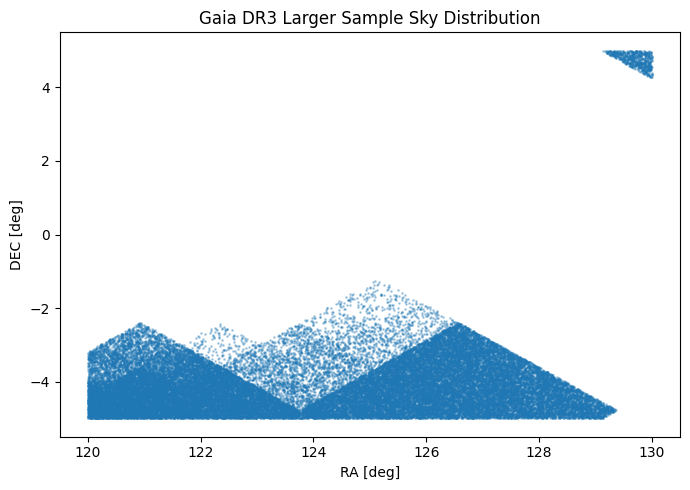

PosixPath('/Users/liors/Documents/gaia-lamost-galactic-archaeology/figures/gaia_lamost_larger_sky_distribution.png')

In [26]:
plt.figure(figsize=(7, 5))

plt.scatter(
    gaia_larger_sample["ra"],
    gaia_larger_sample["dec"],
    s=1,
    alpha=0.3
)

plt.xlabel("RA [deg]")
plt.ylabel("DEC [deg]")
plt.title("Gaia DR3 Larger Sample Sky Distribution")

plt.tight_layout()

gaia_larger_sky_path = FIGURES / "gaia_lamost_larger_sky_distribution.png"
plt.savefig(gaia_larger_sky_path, dpi=200)

plt.show()

gaia_larger_sky_path

### 4.1 Sky Distribution Note

The Gaia larger-sample sky distribution confirms that the query reached the intended general sky region.

However, the coverage is not spatially uniform across the full RA–DEC rectangle.

This is likely because the query used:

```text
SELECT TOP 50000
```

Therefore, the current Gaia larger sample should be interpreted as a truncated subset of the full quality-filtered region, rather than a complete spatially uniform sample of all Gaia DR3 sources in this sky area.

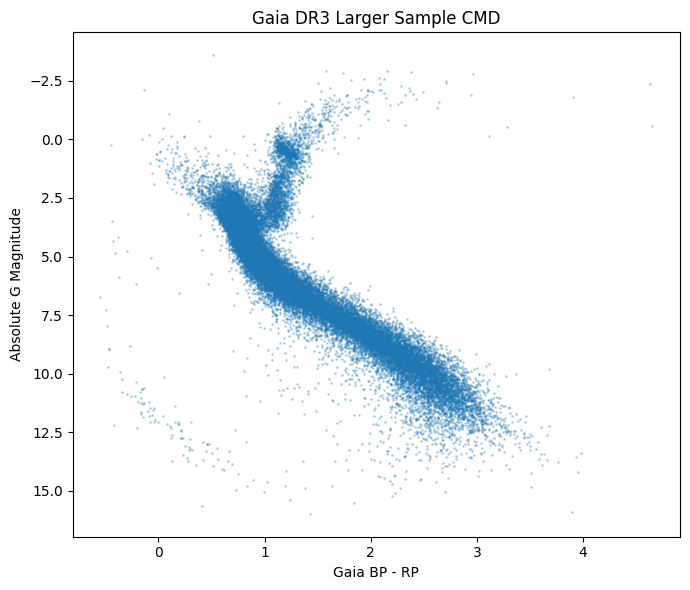

PosixPath('/Users/liors/Documents/gaia-lamost-galactic-archaeology/figures/gaia_lamost_larger_cmd.png')

In [27]:
plt.figure(figsize=(7, 6))

plt.scatter(
    gaia_larger_sample["bp_rp"],
    gaia_larger_sample["absolute_g_mag"],
    s=1,
    alpha=0.25
)

plt.gca().invert_yaxis()

plt.xlabel("Gaia BP - RP")
plt.ylabel("Absolute G Magnitude")
plt.title("Gaia DR3 Larger Sample CMD")

plt.tight_layout()

gaia_larger_cmd_path = FIGURES / "gaia_lamost_larger_cmd.png"
plt.savefig(gaia_larger_cmd_path, dpi=200)

plt.show()

gaia_larger_cmd_path

### 4.2 CMD Validation Note

The Gaia larger-sample CMD shows the expected broad stellar-population structure.

Visible features include:

```text
- a clear main sequence
- a red giant branch
- a sparse population of outliers
```

This indicates that the basic Gaia feature construction is working properly, especially for:

```text
distance_pc
absolute_g_mag
bp_rp
```

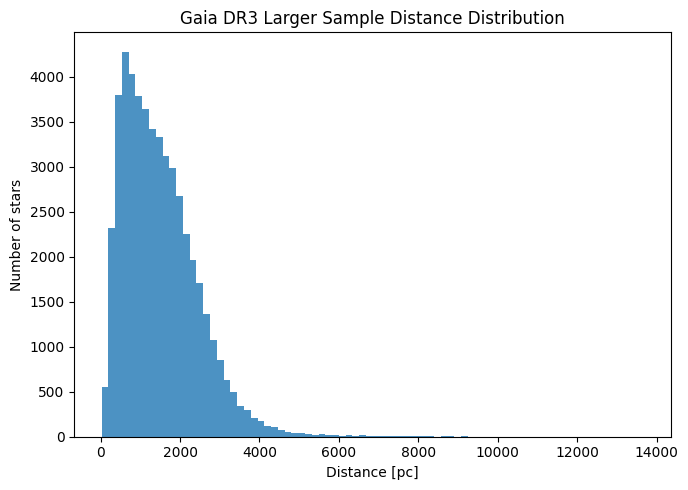

PosixPath('/Users/liors/Documents/gaia-lamost-galactic-archaeology/figures/gaia_lamost_larger_distance_distribution.png')

In [28]:
plt.figure(figsize=(7, 5))

plt.hist(
    gaia_larger_sample["distance_pc"],
    bins=80,
    alpha=0.8
)

plt.xlabel("Distance [pc]")
plt.ylabel("Number of stars")
plt.title("Gaia DR3 Larger Sample Distance Distribution")

plt.tight_layout()

gaia_larger_distance_path = FIGURES / "gaia_lamost_larger_distance_distribution.png"
plt.savefig(gaia_larger_distance_path, dpi=200)

plt.show()

gaia_larger_distance_path

### 4.3 Distance Distribution Note

The Gaia larger-sample distance distribution is strongly right-skewed.

Main observations:

```text
- most stars are concentrated at relatively nearby distances
- the distribution shows a long tail toward larger distances
- this is consistent with the parallax-based distance summary statistics
```

This supports that the basic distance construction:

```text
distance_pc = 1000 / parallax
```

is working as expected for the current Gaia larger sample.

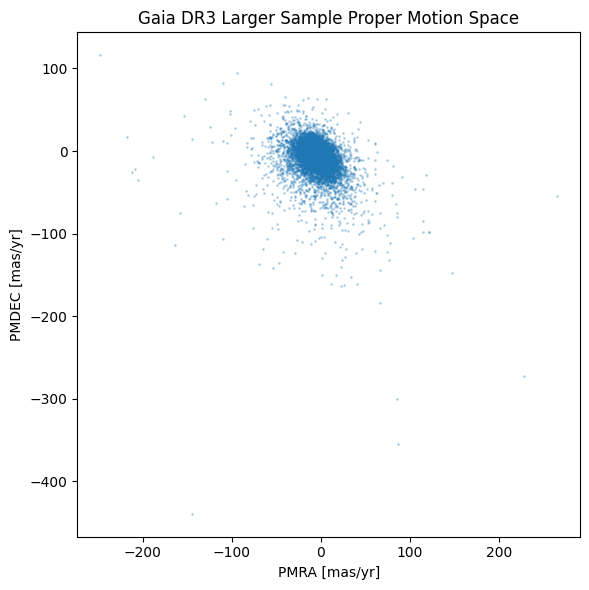

PosixPath('/Users/liors/Documents/gaia-lamost-galactic-archaeology/figures/gaia_lamost_larger_proper_motion_space.png')

In [29]:
plt.figure(figsize=(6, 6))

plt.scatter(
    gaia_larger_sample["pmra"],
    gaia_larger_sample["pmdec"],
    s=1,
    alpha=0.25
)

plt.xlabel("PMRA [mas/yr]")
plt.ylabel("PMDEC [mas/yr]")
plt.title("Gaia DR3 Larger Sample Proper Motion Space")

plt.tight_layout()

gaia_larger_pm_path = FIGURES / "gaia_lamost_larger_proper_motion_space.png"
plt.savefig(gaia_larger_pm_path, dpi=200)

plt.show()

gaia_larger_pm_path

### 4.4 Proper Motion Space Note

The Gaia larger-sample proper motion distribution appears broadly well-behaved.

Main observations:

```text
- most stars are concentrated in a compact central proper-motion region
- a small number of outliers extend to larger absolute proper motions
- no major structural problems are visible in the pmra–pmdec plane
```

This suggests that the Gaia proper-motion measurements:

```text
pmra
pmdec
```

are suitable for the next-stage kinematic preparation.

## 5. Interim Milestone 4 Summary

At this stage, Milestone 4 has completed the Gaia-side larger sample preparation.

Completed tasks:

```text
1. Created notebooks/04_larger_sample_kinematic_preparation.ipynb
2. Defined the larger sample sky region
3. Prepared reusable LAMOST column-standardization and reading functions
4. Confirmed that the larger LAMOST sample is not yet available locally
5. Queried Gaia DR3 for the larger Milestone 4 sky region
6. Saved the Gaia larger raw sample
7. Constructed basic Gaia features
8. Saved the Gaia larger processed feature table
9. Generated Gaia larger validation plots
```

Gaia larger sample outputs:

```text
data/raw/gaia_dr3_larger_lamost_region_sample.csv
Shape: 50000 stars × 10 columns

data/processed/gaia_dr3_larger_lamost_region_with_features.csv
Shape: 50000 stars × 12 columns
```

Generated figures:

```text
figures/gaia_lamost_larger_sky_distribution.png
figures/gaia_lamost_larger_cmd.png
figures/gaia_lamost_larger_distance_distribution.png
figures/gaia_lamost_larger_proper_motion_space.png
```

Current limitation:

```text
The larger LAMOST sample has not yet been obtained.
```

Next steps:

```text
1. Obtain or import data/raw/lamost_dr9_larger_sample.csv
2. Read and standardize the larger LAMOST sample
3. Perform Gaia–LAMOST source_id cross-match
4. Validate coordinate separation
5. Construct larger-sample chemo-kinematic features
6. Prepare Galactic coordinates and UVW input fields
```

## 6. Gaia–LAMOST Larger Sample Coordinate Cross-match

Because the larger LAMOST export does not include `gaia_source_id`, the larger-sample cross-match will use sky coordinates.

Matching strategy:

```text
1. Build SkyCoord objects for Gaia and LAMOST.
2. Match each LAMOST source to the nearest Gaia source.
3. Test several angular separation thresholds:
   - 0.5 arcsec
   - 1.0 arcsec
   - 2.0 arcsec
   - 3.0 arcsec
4. Select a conservative matching radius after checking match counts.
```

For this larger sample, coordinate cross-match is used as the primary method.

In [33]:
gaia_coord = SkyCoord(
    ra=gaia_larger_sample["ra"].values * u.deg,
    dec=gaia_larger_sample["dec"].values * u.deg,
    frame="icrs"
)

lamost_coord = SkyCoord(
    ra=lamost_larger["ra_lamost"].values * u.deg,
    dec=lamost_larger["dec_lamost"].values * u.deg,
    frame="icrs"
)

print("Gaia coordinates:", len(gaia_coord))
print("LAMOST coordinates:", len(lamost_coord))

Gaia coordinates: 50000
LAMOST coordinates: 2979


In [34]:
idx, sep2d, _ = lamost_coord.match_to_catalog_sky(gaia_coord)

for radius in [0.5, 1.0, 2.0, 3.0]:
    n_match = np.sum(sep2d < radius * u.arcsec)
    print(f"{radius:3.1f} arcsec: {n_match} matches")

sep2d.arcsec[:10]

0.5 arcsec: 0 matches
1.0 arcsec: 0 matches
2.0 arcsec: 0 matches
3.0 arcsec: 0 matches


array([ 6775.86640649,  7370.46994987, 10552.75843604, 10085.52172417,
        8832.5870799 ,  8416.3146261 ,  7917.60441457,  7962.50952038,
        9769.65920033,  9993.41033205])

In [35]:
lamost_region_for_gaia = {
    "ra_min": lamost_larger["ra_lamost"].min() - 0.05,
    "ra_max": lamost_larger["ra_lamost"].max() + 0.05,
    "dec_min": lamost_larger["dec_lamost"].min() - 0.05,
    "dec_max": lamost_larger["dec_lamost"].max() + 0.05,
}

lamost_region_for_gaia

{'ra_min': np.float64(119.952082),
 'ra_max': np.float64(125.045881),
 'dec_min': np.float64(-0.049371000000000005),
 'dec_max': np.float64(2.049934)}

In [36]:
gaia_lamost_region_query = f"""
SELECT
    source_id,
    ra,
    dec,
    parallax,
    parallax_over_error,
    pmra,
    pmdec,
    phot_g_mean_mag,
    bp_rp,
    ruwe
FROM gaiadr3.gaia_source
WHERE ra BETWEEN {lamost_region_for_gaia["ra_min"]} AND {lamost_region_for_gaia["ra_max"]}
  AND dec BETWEEN {lamost_region_for_gaia["dec_min"]} AND {lamost_region_for_gaia["dec_max"]}
  AND parallax IS NOT NULL
  AND parallax > 0
  AND parallax_over_error > 5
  AND pmra IS NOT NULL
  AND pmdec IS NOT NULL
  AND phot_g_mean_mag IS NOT NULL
  AND bp_rp IS NOT NULL
  AND ruwe < 1.4
"""

print(gaia_lamost_region_query)


SELECT
    source_id,
    ra,
    dec,
    parallax,
    parallax_over_error,
    pmra,
    pmdec,
    phot_g_mean_mag,
    bp_rp,
    ruwe
FROM gaiadr3.gaia_source
WHERE ra BETWEEN 119.952082 AND 125.045881
  AND dec BETWEEN -0.049371000000000005 AND 2.049934
  AND parallax IS NOT NULL
  AND parallax > 0
  AND parallax_over_error > 5
  AND pmra IS NOT NULL
  AND pmdec IS NOT NULL
  AND phot_g_mean_mag IS NOT NULL
  AND bp_rp IS NOT NULL
  AND ruwe < 1.4



In [37]:
job = Gaia.launch_job_async(gaia_lamost_region_query)
gaia_lamost_region_sample = job.get_results().to_pandas()

gaia_lamost_region_sample.shape

INFO: Query finished. [astroquery.utils.tap.core]


(36531, 10)

In [38]:
gaia_lamost_region_sample["distance_pc"] = 1000.0 / gaia_lamost_region_sample["parallax"]

gaia_lamost_region_sample["absolute_g_mag"] = (
    gaia_lamost_region_sample["phot_g_mean_mag"]
    - 5 * np.log10(gaia_lamost_region_sample["distance_pc"])
    + 5
)

print(gaia_lamost_region_sample.shape)

gaia_lamost_region_sample[
    ["parallax", "distance_pc", "phot_g_mean_mag", "absolute_g_mag", "bp_rp"]
].describe()

(36531, 12)


,parallax,distance_pc,phot_g_mean_mag,absolute_g_mag,bp_rp
count,36531.000000,36531.000000,36531.000000,36531.000000,36531.000000
mean,1.128553,1455.482571,16.236477,5.890204,1.293950
std,1.271495,932.461229,1.765351,2.563692,0.629025
min,0.075795,8.938965,6.666027,-3.244473,-1.350478
25%,0.502663,741.152583,15.244735,4.076770,0.826165
50%,0.769902,1298.867094,16.374512,5.484739,1.058599
75%,1.349250,1989.404043,17.423285,7.540011,1.652460
max,111.869777,13193.564091,20.638805,15.743736,4.595585


In [39]:
gaia_lamost_region_coord = SkyCoord(
    ra=gaia_lamost_region_sample["ra"].values * u.deg,
    dec=gaia_lamost_region_sample["dec"].values * u.deg,
    frame="icrs"
)

idx_lamost_region, sep2d_lamost_region, _ = lamost_coord.match_to_catalog_sky(
    gaia_lamost_region_coord
)

for radius in [0.5, 1.0, 2.0, 3.0]:
    n_match = np.sum(sep2d_lamost_region < radius * u.arcsec)
    print(f"{radius:3.1f} arcsec: {n_match} matches")

sep2d_lamost_region.arcsec[:10]

0.5 arcsec: 2405 matches
1.0 arcsec: 2487 matches
2.0 arcsec: 2501 matches
3.0 arcsec: 2509 matches


array([13.94752704,  4.90855779,  0.02356049,  0.11854423,  0.0744307 ,
        2.4050238 ,  0.2319649 ,  1.10510694,  0.04863211,  1.19900927])

### 6.1 Coordinate Cross-match Radius Selection

The coordinate cross-match was tested with several angular separation thresholds:

```text
0.5 arcsec: 2405 matches
1.0 arcsec: 2487 matches
2.0 arcsec: 2501 matches
3.0 arcsec: 2509 matches
```

The match count increases only slightly from 1.0 arcsec to 2.0 arcsec.

Therefore, this notebook adopts a conservative default matching radius:

```text
1.0 arcsec
```

This gives a larger Gaia–LAMOST coordinate-matched sample while keeping the angular separation threshold reasonably strict.

In [40]:
match_radius = 1.0 * u.arcsec

match_mask = sep2d_lamost_region < match_radius

lamost_matched = lamost_larger.loc[match_mask].copy().reset_index(drop=True)

gaia_matched = (
    gaia_lamost_region_sample
    .iloc[idx_lamost_region[match_mask]]
    .copy()
    .reset_index(drop=True)
)

print("LAMOST matched:", lamost_matched.shape)
print("Gaia matched:", gaia_matched.shape)

LAMOST matched: (2487, 16)
Gaia matched: (2487, 12)


In [41]:
gaia_matched_renamed = gaia_matched.rename(
    columns={
        "ra": "ra_gaia",
        "dec": "dec_gaia",
    }
)

gaia_lamost_larger_crossmatched = pd.concat(
    [gaia_matched_renamed, lamost_matched],
    axis=1
)

gaia_lamost_larger_crossmatched["coord_match_sep_arcsec"] = (
    sep2d_lamost_region[match_mask].arcsec
)

print(gaia_lamost_larger_crossmatched.shape)

gaia_lamost_larger_crossmatched.head()

(2487, 29)


,source_id,ra_gaia,dec_gaia,parallax,parallax_over_error,pmra,pmdec,phot_g_mean_mag,bp_rp,ruwe,...,combined_class,combined_subclass,combined_z,ra_lamost,dec_lamost,feh,logg,rv,teff,coord_match_sep_arcsec
0,3089799717558002432,123.491552,1.181119,0.523239,18.185474,-0.675059,-0.127367,15.216306,0.621837,1.015230,...,STAR,F3,0.000084,123.491558,1.181120,-0.354,4.251,25.16,6556.22,0.023560
1,3089762883918526336,123.348778,0.922533,0.480921,16.692497,-6.119573,1.472251,14.836842,0.613451,0.937514,...,STAR,F3,0.000235,123.348810,0.922526,-0.402,4.176,70.52,6643.07,0.118544
2,3089588267727250048,123.874964,0.853229,0.588702,21.468010,-3.762318,-3.631529,14.848082,0.837086,1.050417,...,STAR,F9,0.000122,123.874980,0.853242,0.152,4.089,36.49,5791.55,0.074431
3,3089533463944733184,124.150223,0.708658,1.078994,35.536400,-14.183513,-4.030378,15.151126,1.012721,0.962530,...,STAR,K1,0.000240,124.150278,0.708692,0.239,4.471,71.87,5285.36,0.231965
4,3089606581467789184,123.681657,1.042498,1.166740,50.402496,-1.314243,-4.316718,14.426936,0.855072,1.001385,...,STAR,G3,0.000278,123.681659,1.042511,-0.127,4.350,83.30,5719.79,0.048632


In [42]:
gaia_lamost_larger_crossmatched["coord_match_sep_arcsec"].describe()

count    2487.000000
mean        0.141098
std         0.134491
min         0.001647
25%         0.061066
50%         0.099322
75%         0.166090
max         0.973660
Name: coord_match_sep_arcsec, dtype: float64

In [43]:
larger_crossmatched_path = DATA_PROCESSED / "gaia_lamost_larger_crossmatched_sample.csv"

gaia_lamost_larger_crossmatched.to_csv(larger_crossmatched_path, index=False)

print("Saved larger Gaia-LAMOST crossmatched sample:")
print(larger_crossmatched_path)
print("Shape:", gaia_lamost_larger_crossmatched.shape)

Saved larger Gaia-LAMOST crossmatched sample:
/Users/liors/Documents/gaia-lamost-galactic-archaeology/data/processed/gaia_lamost_larger_crossmatched_sample.csv
Shape: (2487, 29)


### 6.2 Larger Gaia–LAMOST Cross-match Summary

The larger Gaia–LAMOST coordinate cross-match was completed successfully.

Input samples:

```text
LAMOST larger sample:
2979 rows × 16 columns

Gaia LAMOST-region sample:
36531 stars × 12 columns
```

Cross-match method:

```text
Coordinate-based nearest-neighbor matching with SkyCoord
Matching radius: 1.0 arcsec
```

Output:

```text
data/processed/gaia_lamost_larger_crossmatched_sample.csv
Shape: 2487 stars × 29 columns
```

Coordinate separation statistics:

```text
mean separation:   0.141 arcsec
median separation: 0.099 arcsec
max separation:    0.974 arcsec
```

Interpretation:

The larger coordinate-matched sample is substantially larger than the Milestone 2 pilot sample and has well-controlled angular separations under the adopted 1.0 arcsec threshold.

## 7. Larger Sample Chemo-kinematic Feature Construction

This section reconstructs the Milestone 3 chemo-kinematic features for the larger Gaia–LAMOST coordinate-matched sample.

Features to construct:

```text
pm_total
tangential_velocity_kms
reduced_pm_g
metallicity_group
high_vtan_candidate
metal_poor_candidate
chemo_kinematic_candidate
```

These features prepare the larger matched sample for later population-separation and clustering analysis.

In [44]:
larger_features = gaia_lamost_larger_crossmatched.copy()

print(larger_features.shape)
larger_features[[
    "source_id",
    "ra_gaia",
    "dec_gaia",
    "parallax",
    "pmra",
    "pmdec",
    "phot_g_mean_mag",
    "bp_rp",
    "feh",
    "rv"
]].head()

(2487, 29)


,source_id,ra_gaia,dec_gaia,parallax,pmra,pmdec,phot_g_mean_mag,bp_rp,feh,rv
0,3089799717558002432,123.491552,1.181119,0.523239,-0.675059,-0.127367,15.216306,0.621837,-0.354,25.16
1,3089762883918526336,123.348778,0.922533,0.480921,-6.119573,1.472251,14.836842,0.613451,-0.402,70.52
2,3089588267727250048,123.874964,0.853229,0.588702,-3.762318,-3.631529,14.848082,0.837086,0.152,36.49
3,3089533463944733184,124.150223,0.708658,1.078994,-14.183513,-4.030378,15.151126,1.012721,0.239,71.87
4,3089606581467789184,123.681657,1.042498,1.166740,-1.314243,-4.316718,14.426936,0.855072,-0.127,83.30


In [45]:
larger_features["pm_total"] = np.sqrt(
    larger_features["pmra"]**2 + larger_features["pmdec"]**2
)

larger_features["tangential_velocity_kms"] = (
    4.74047 * larger_features["pm_total"] / larger_features["parallax"]
)

larger_features[[
    "pmra",
    "pmdec",
    "pm_total",
    "parallax",
    "tangential_velocity_kms"
]].describe()

,pmra,pmdec,pm_total,parallax,tangential_velocity_kms
count,2487.000000,2487.000000,2487.000000,2487.000000,2487.000000
mean,-3.988405,-3.267394,9.646306,1.383430,36.665879
std,8.623172,8.910667,9.341539,1.117166,28.410579
min,-75.862201,-74.081247,0.146078,0.075795,1.275461
25%,-6.790784,-5.818573,3.805494,0.601101,20.225309
50%,-3.152884,-1.613446,6.573673,1.087065,32.312766
75%,-0.333392,1.109988,11.804670,1.729340,45.764104
max,39.171390,33.408061,78.717053,10.088751,426.686109


In [46]:
pm_total_arcsec_per_year = larger_features["pm_total"] / 1000.0

larger_features["reduced_pm_g"] = (
    larger_features["phot_g_mean_mag"]
    + 5 * np.log10(pm_total_arcsec_per_year)
    + 5
)

larger_features[[
    "phot_g_mean_mag",
    "pm_total",
    "reduced_pm_g"
]].describe()

,phot_g_mean_mag,pm_total,reduced_pm_g
count,2487.000000,2487.000000,2487.000000
mean,12.917587,9.646306,7.015284
std,1.242110,9.341539,2.090344
min,8.640154,0.146078,-2.421182
25%,12.111635,3.805494,5.655477
50%,12.890983,6.573673,7.122570
75%,13.656799,11.804670,8.490289
max,16.678677,78.717053,13.488025


In [47]:
def classify_metallicity(feh: float) -> str:
    if pd.isna(feh):
        return "unknown"
    if feh < -0.5:
        return "metal_poor"
    if feh > 0.2:
        return "metal_rich"
    return "solar_like"


larger_features["metallicity_group"] = larger_features["feh"].apply(classify_metallicity)

larger_features["metallicity_group"].value_counts()

metallicity_group
solar_like    2135
metal_poor     186
metal_rich     166
Name: count, dtype: int64

In [48]:
larger_features["high_vtan_candidate"] = (
    larger_features["tangential_velocity_kms"] > 100
)

larger_features["metal_poor_candidate"] = (
    larger_features["feh"] < -0.5
)

larger_features["chemo_kinematic_candidate"] = (
    larger_features["high_vtan_candidate"]
    & larger_features["metal_poor_candidate"]
)

larger_features[[
    "high_vtan_candidate",
    "metal_poor_candidate",
    "chemo_kinematic_candidate"
]].sum()

high_vtan_candidate           41
metal_poor_candidate         186
chemo_kinematic_candidate     29
dtype: int64

In [49]:
candidate_preview = (
    larger_features[larger_features["chemo_kinematic_candidate"]]
    .sort_values("tangential_velocity_kms", ascending=False)
)

candidate_preview[[
    "source_id",
    "ra_gaia",
    "dec_gaia",
    "bp_rp",
    "phot_g_mean_mag",
    "absolute_g_mag",
    "feh",
    "rv",
    "pm_total",
    "tangential_velocity_kms",
    "coord_match_sep_arcsec"
]].head(10)

,source_id,ra_gaia,dec_gaia,bp_rp,phot_g_mean_mag,absolute_g_mag,feh,rv,pm_total,tangential_velocity_kms,coord_match_sep_arcsec
927,3089944573918027648,123.954966,1.686693,0.984529,12.667116,1.568062,-1.472,385.54,54.259554,426.686109,0.352205
10,3089847099636770560,122.508355,1.280094,0.618819,14.704865,3.726077,-2.213,-11.29,55.604915,413.706467,0.863182
1625,3089534353001157632,124.176994,0.737449,1.041462,12.563370,0.871324,-1.539,-43.26,36.399246,376.116952,0.594215
2233,3084095863550902528,120.430550,0.240808,0.728496,15.136126,2.774414,-1.723,9.04,25.438048,357.805943,0.164463
676,3084565217577674368,121.570063,0.938306,1.213599,13.518031,-1.499764,-1.679,90.96,6.358696,303.912486,0.141890
2435,3083736976083264768,122.770014,0.422235,0.703481,16.196064,3.590142,-0.583,-1.81,15.376273,242.023175,0.233348
2077,3083553117121981312,123.113104,0.459705,1.549932,13.163137,-2.438673,-1.116,91.38,3.797959,237.538396,0.058795
2389,3089780884124744832,123.074390,1.055596,0.772332,15.846841,5.025141,-1.369,71.17,33.747128,233.559855,0.514425
1422,3084599680395408128,121.843549,1.174597,1.454281,12.519477,-0.993649,-0.800,-3.50,9.764565,233.399309,0.103622
457,3084599680395408128,121.843549,1.174597,1.454281,12.519477,-0.993649,-0.748,-3.95,9.764565,233.399309,0.103622


In [50]:
duplicate_source_count = larger_features["source_id"].duplicated().sum()
unique_source_count = larger_features["source_id"].nunique()

print("Total rows:", len(larger_features))
print("Unique Gaia source_id:", unique_source_count)
print("Duplicate rows by source_id:", duplicate_source_count)

Total rows: 2487
Unique Gaia source_id: 1838
Duplicate rows by source_id: 649


In [51]:
larger_features_dedup = (
    larger_features
    .sort_values("coord_match_sep_arcsec")
    .drop_duplicates(subset="source_id", keep="first")
    .reset_index(drop=True)
)

print("Before deduplication:", larger_features.shape)
print("After deduplication:", larger_features_dedup.shape)
print("Unique source_id:", larger_features_dedup["source_id"].nunique())

Before deduplication: (2487, 36)
After deduplication: (1838, 36)
Unique source_id: 1838


In [52]:
larger_features_dedup[[
    "high_vtan_candidate",
    "metal_poor_candidate",
    "chemo_kinematic_candidate"
]].sum()

high_vtan_candidate           38
metal_poor_candidate         148
chemo_kinematic_candidate     27
dtype: int64

### 7.1 Duplicate Gaia Source Handling

The coordinate-matched larger sample contains repeated Gaia `source_id` values because a single Gaia source may have multiple LAMOST observations.

Duplicate check:

```text
Matched observation-level rows: 2487
Unique Gaia source_id: 1838
Duplicate rows by source_id: 649
```

Deduplication strategy:

```text
For each Gaia source_id, keep the row with the smallest coord_match_sep_arcsec.
```

This produces a star-level larger feature table:

```text
1838 unique Gaia sources × 36 columns
```

Candidate counts after deduplication:

```text
high_vtan_candidate:          38
metal_poor_candidate:        148
chemo_kinematic_candidate:    27
```

The deduplicated table will be used as the main larger-sample analysis-ready feature table.

In [53]:
larger_features_path = DATA_PROCESSED / "gaia_lamost_larger_chemo_kinematic_features.csv"

larger_features_dedup.to_csv(larger_features_path, index=False)

print("Saved larger chemo-kinematic feature table:")
print(larger_features_path)
print("Shape:", larger_features_dedup.shape)

Saved larger chemo-kinematic feature table:
/Users/liors/Documents/gaia-lamost-galactic-archaeology/data/processed/gaia_lamost_larger_chemo_kinematic_features.csv
Shape: (1838, 36)


### 7.2 Larger Chemo-kinematic Feature Table Summary

The deduplicated larger Gaia–LAMOST chemo-kinematic feature table was saved successfully.

Output file:

```text
data/processed/gaia_lamost_larger_chemo_kinematic_features.csv
```

Shape:

```text
1838 unique Gaia sources × 36 columns
```

Constructed features:

```text
pm_total
tangential_velocity_kms
reduced_pm_g
metallicity_group
high_vtan_candidate
metal_poor_candidate
chemo_kinematic_candidate
```

Candidate counts:

```text
high_vtan_candidate:          38
metal_poor_candidate:        148
chemo_kinematic_candidate:    27
```

This table is the current Milestone 4 larger-sample analysis-ready table.

## 8. Galactic Coordinate Preparation

This section converts the larger Gaia–LAMOST star-level sample from ICRS coordinates to Galactic coordinates.

Input coordinates:

```text
ra_gaia
dec_gaia
```

Output features:

```text
gal_l
gal_b
```

These Galactic coordinates prepare the sample for later Milky Way population analysis and UVW velocity construction.

In [54]:
larger_star_coord = SkyCoord(
    ra=larger_features_dedup["ra_gaia"].values * u.deg,
    dec=larger_features_dedup["dec_gaia"].values * u.deg,
    frame="icrs"
)

larger_star_galactic = larger_star_coord.galactic

larger_features_dedup["gal_l"] = larger_star_galactic.l.deg
larger_features_dedup["gal_b"] = larger_star_galactic.b.deg

larger_features_dedup[[
    "ra_gaia",
    "dec_gaia",
    "gal_l",
    "gal_b"
]].head()

,ra_gaia,dec_gaia,gal_l,gal_b
0,123.585870,1.280288,221.534140,18.970509
1,121.883921,1.744536,220.257275,17.689465
2,121.847440,0.277612,221.593783,16.964606
3,122.455011,0.252453,221.919714,17.486961
4,120.988708,1.818766,219.749788,16.933549


In [55]:
larger_features_dedup.to_csv(larger_features_path, index=False)

print("Updated larger chemo-kinematic feature table with Galactic coordinates:")
print(larger_features_path)
print("Shape:", larger_features_dedup.shape)
print("New columns:", ["gal_l", "gal_b"])

Updated larger chemo-kinematic feature table with Galactic coordinates:
/Users/liors/Documents/gaia-lamost-galactic-archaeology/data/processed/gaia_lamost_larger_chemo_kinematic_features.csv
Shape: (1838, 38)
New columns: ['gal_l', 'gal_b']


### 8.1 Galactic Coordinate Summary

Galactic coordinates were successfully added to the larger star-level Gaia–LAMOST feature table.

Input coordinates:

```text
ra_gaia
dec_gaia
```

Added columns:

```text
gal_l
gal_b
```

Updated output file:

```text
data/processed/gaia_lamost_larger_chemo_kinematic_features.csv
```

Updated shape:

```text
1838 unique Gaia sources × 38 columns
```

These columns prepare the sample for later Milky Way population analysis and UVW velocity construction.

## 9. UVW Velocity Input Preparation

This section checks whether the larger star-level Gaia–LAMOST feature table contains the required input fields for future UVW velocity construction.

Required fields:

```text
ra_gaia
dec_gaia
distance_pc
pmra
pmdec
rv
```

These fields are needed to construct a full astrometric + radial-velocity `SkyCoord` object.

Formal UVW velocity calculation can be performed in a later milestone after additional validation.

In [56]:
uvw_required_cols = [
    "ra_gaia",
    "dec_gaia",
    "distance_pc",
    "pmra",
    "pmdec",
    "rv",
]

uvw_field_check = pd.DataFrame({
    "column": uvw_required_cols,
    "exists": [col in larger_features_dedup.columns for col in uvw_required_cols],
    "missing_count": [
        larger_features_dedup[col].isna().sum() if col in larger_features_dedup.columns else None
        for col in uvw_required_cols
    ],
    "missing_fraction": [
        larger_features_dedup[col].isna().mean() if col in larger_features_dedup.columns else None
        for col in uvw_required_cols
    ],
})

uvw_field_check

,column,exists,missing_count,missing_fraction
0,ra_gaia,True,0,0.0
1,dec_gaia,True,0,0.0
2,distance_pc,True,0,0.0
3,pmra,True,0,0.0
4,pmdec,True,0,0.0
5,rv,True,0,0.0


### 9.1 UVW Input Field Check Summary

The larger star-level Gaia–LAMOST feature table contains all required input fields for future UVW velocity construction.

Required fields checked:

```text
ra_gaia
dec_gaia
distance_pc
pmra
pmdec
rv
```

Result:

```text
All required fields are present.
No missing values were found in these columns.
```

This means the current larger feature table is ready for future full 3D velocity construction using Gaia astrometry and LAMOST radial velocities.

Formal UVW velocity calculation will be handled in a later milestone after additional validation of coordinate conventions and solar-motion assumptions.

## 10. Larger Gaia–LAMOST Feature Validation Plots

This section generates validation plots for the final deduplicated larger Gaia–LAMOST feature table.

The plots check:

```text
tangential_velocity_kms distribution
tangential_velocity_kms vs [Fe/H]
CMD colored by tangential_velocity_kms
reduced proper motion diagram
Galactic l-b distribution
```

These figures validate the larger chemo-kinematic feature table and prepare the project for later clustering and population-separation analysis.

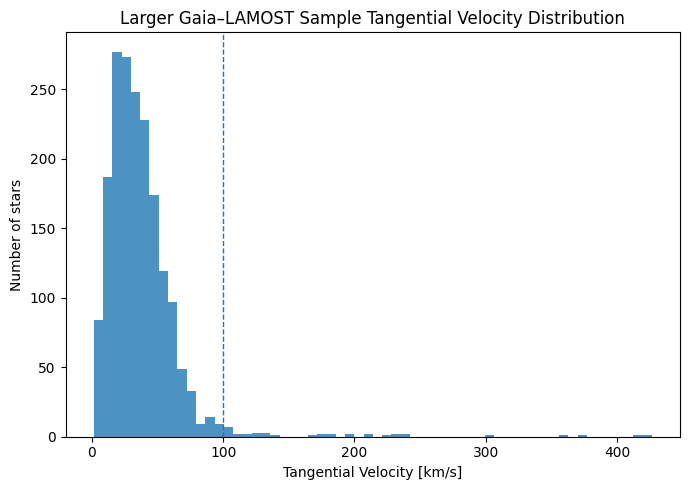

PosixPath('/Users/liors/Documents/gaia-lamost-galactic-archaeology/figures/gaia_lamost_larger_vtan_distribution.png')

In [57]:
plt.figure(figsize=(7, 5))

plt.hist(
    larger_features_dedup["tangential_velocity_kms"],
    bins=60,
    alpha=0.8
)

plt.axvline(100, linestyle="--", linewidth=1)

plt.xlabel("Tangential Velocity [km/s]")
plt.ylabel("Number of stars")
plt.title("Larger Gaia–LAMOST Sample Tangential Velocity Distribution")

plt.tight_layout()

larger_vtan_distribution_path = FIGURES / "gaia_lamost_larger_vtan_distribution.png"
plt.savefig(larger_vtan_distribution_path, dpi=200)

plt.show()

larger_vtan_distribution_path

### 10.1 Tangential Velocity Distribution Note

The larger Gaia–LAMOST star-level sample shows a strongly right-skewed tangential velocity distribution.

Main observations:

```text
- most stars have tangential velocities below 100 km/s
- a small high-velocity tail extends beyond 100 km/s
- the dashed vertical line marks the high-vtan candidate threshold
```

The current high-vtan threshold is:

```text
tangential_velocity_kms > 100
```

This threshold identifies 38 high-vtan candidates in the deduplicated larger sample.

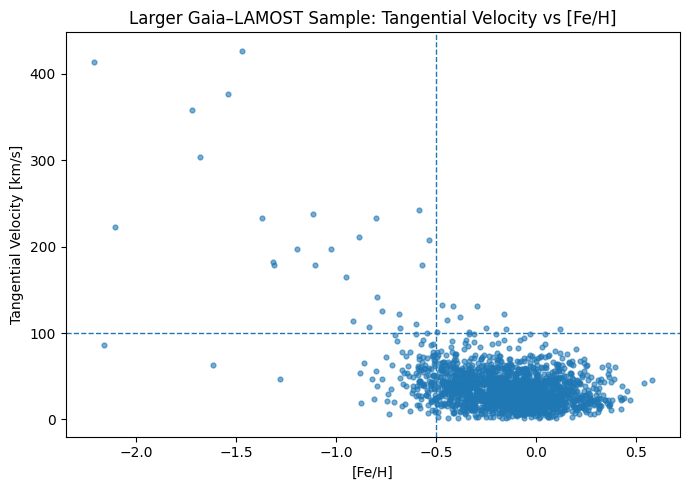

PosixPath('/Users/liors/Documents/gaia-lamost-galactic-archaeology/figures/gaia_lamost_larger_vtan_vs_feh.png')

In [58]:
plt.figure(figsize=(7, 5))

plt.scatter(
    larger_features_dedup["feh"],
    larger_features_dedup["tangential_velocity_kms"],
    s=12,
    alpha=0.6
)

plt.axhline(100, linestyle="--", linewidth=1)
plt.axvline(-0.5, linestyle="--", linewidth=1)

plt.xlabel("[Fe/H]")
plt.ylabel("Tangential Velocity [km/s]")
plt.title("Larger Gaia–LAMOST Sample: Tangential Velocity vs [Fe/H]")

plt.tight_layout()

larger_vtan_feh_path = FIGURES / "gaia_lamost_larger_vtan_vs_feh.png"
plt.savefig(larger_vtan_feh_path, dpi=200)

plt.show()

larger_vtan_feh_path

### 10.2 Tangential Velocity vs Metallicity Note

The larger Gaia–LAMOST sample shows a clear separation between the main low-velocity population and a smaller high-velocity, metal-poor tail.

Selection thresholds:

```text
tangential_velocity_kms > 100
[Fe/H] < -0.5
```

These thresholds define the current larger-sample chemo-kinematic candidate region.

Candidate count after deduplication:

```text
chemo_kinematic_candidate: 27
```

This result demonstrates the main value of the Milestone 4 larger-sample expansion: the pilot workflow now identifies a non-empty set of metal-poor high-velocity candidates suitable for later population analysis.

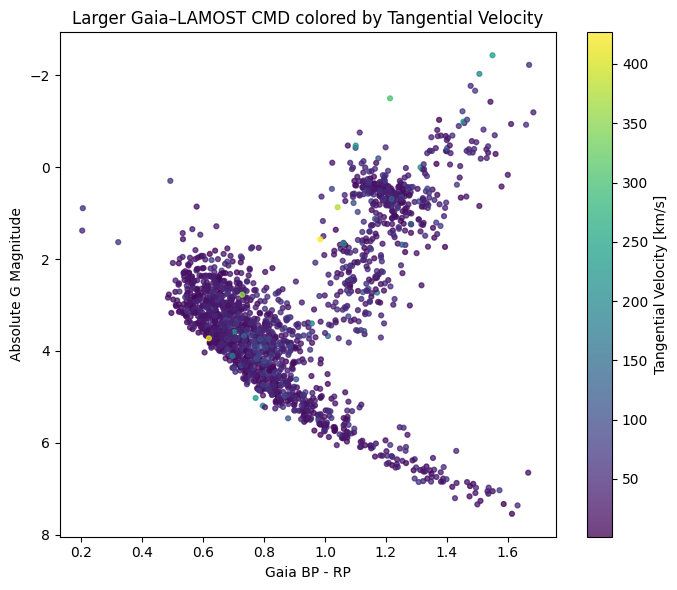

PosixPath('/Users/liors/Documents/gaia-lamost-galactic-archaeology/figures/gaia_lamost_larger_cmd_colored_by_vtan.png')

In [59]:
plt.figure(figsize=(7, 6))

scatter = plt.scatter(
    larger_features_dedup["bp_rp"],
    larger_features_dedup["absolute_g_mag"],
    c=larger_features_dedup["tangential_velocity_kms"],
    s=12,
    alpha=0.75
)

plt.gca().invert_yaxis()

plt.xlabel("Gaia BP - RP")
plt.ylabel("Absolute G Magnitude")
plt.title("Larger Gaia–LAMOST CMD colored by Tangential Velocity")

cbar = plt.colorbar(scatter)
cbar.set_label("Tangential Velocity [km/s]")

plt.tight_layout()

larger_cmd_vtan_path = FIGURES / "gaia_lamost_larger_cmd_colored_by_vtan.png"
plt.savefig(larger_cmd_vtan_path, dpi=200)

plt.show()

larger_cmd_vtan_path

### 10.3 CMD Colored by Tangential Velocity Note

The larger Gaia–LAMOST CMD colored by tangential velocity shows the stellar-population structure of the deduplicated matched sample.

Main observations:

```text
- the CMD structure is clearly visible
- most stars have relatively low tangential velocities
- a small number of high-vtan objects are present across the CMD
```

This figure confirms that the larger feature table preserves both photometric structure and kinematic information.

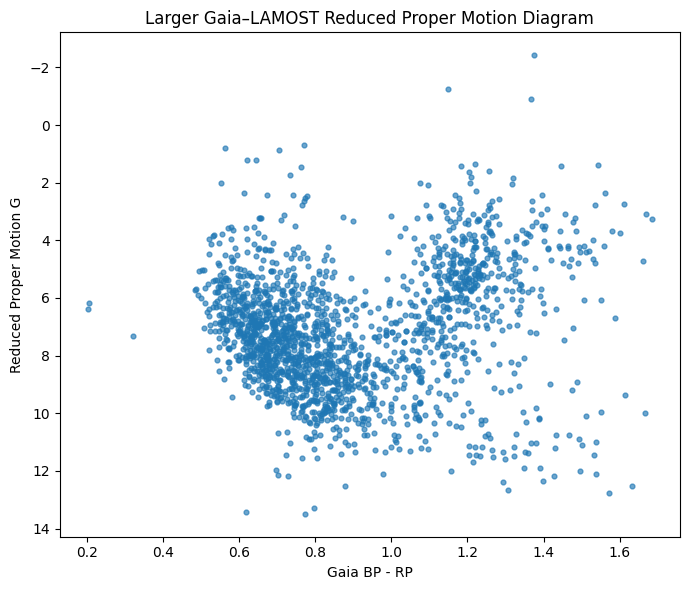

PosixPath('/Users/liors/Documents/gaia-lamost-galactic-archaeology/figures/gaia_lamost_larger_reduced_pm_diagram.png')

In [60]:
plt.figure(figsize=(7, 6))

plt.scatter(
    larger_features_dedup["bp_rp"],
    larger_features_dedup["reduced_pm_g"],
    s=12,
    alpha=0.65
)

plt.gca().invert_yaxis()

plt.xlabel("Gaia BP - RP")
plt.ylabel("Reduced Proper Motion G")
plt.title("Larger Gaia–LAMOST Reduced Proper Motion Diagram")

plt.tight_layout()

larger_reduced_pm_path = FIGURES / "gaia_lamost_larger_reduced_pm_diagram.png"
plt.savefig(larger_reduced_pm_path, dpi=200)

plt.show()

larger_reduced_pm_path

### 10.4 Reduced Proper Motion Diagram Note

The larger Gaia–LAMOST reduced proper motion diagram provides an additional photometric-kinematic validation view.

Main observations:

```text
- the sample shows structured distributions in BP-RP versus reduced proper motion
- the diagram provides a useful check of proper-motion based feature construction
- it can help support later population-separation analysis
```

This figure confirms that the reduced proper motion feature:

```text
reduced_pm_g
```

was successfully constructed for the deduplicated larger sample.

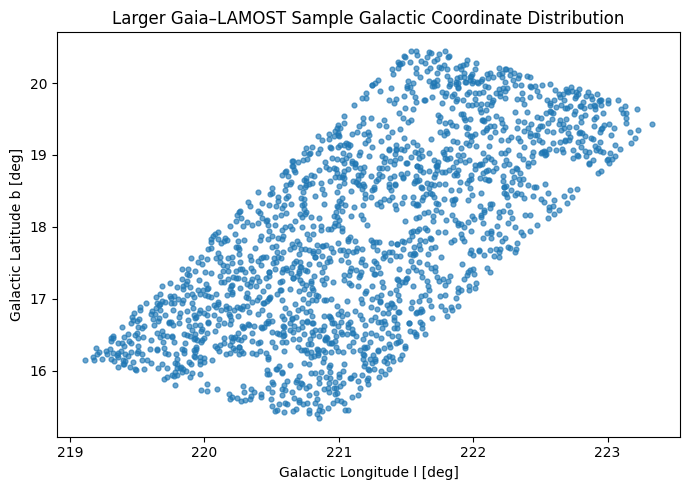

PosixPath('/Users/liors/Documents/gaia-lamost-galactic-archaeology/figures/gaia_lamost_larger_galactic_lb_distribution.png')

In [61]:
plt.figure(figsize=(7, 5))

plt.scatter(
    larger_features_dedup["gal_l"],
    larger_features_dedup["gal_b"],
    s=12,
    alpha=0.65
)

plt.xlabel("Galactic Longitude l [deg]")
plt.ylabel("Galactic Latitude b [deg]")
plt.title("Larger Gaia–LAMOST Sample Galactic Coordinate Distribution")

plt.tight_layout()

larger_gal_lb_path = FIGURES / "gaia_lamost_larger_galactic_lb_distribution.png"
plt.savefig(larger_gal_lb_path, dpi=200)

plt.show()

larger_gal_lb_path

### 10.5 Galactic Coordinate Distribution Note

The larger Gaia–LAMOST Galactic coordinate distribution shows the sky coverage of the final deduplicated matched sample in Galactic coordinates.

Approximate coverage:

```text
gal_l: 219–223 deg
gal_b: 15.5–20.5 deg
```

This confirms that the Galactic coordinate conversion was successful and that the final larger sample occupies a compact Milky Way sky region.

The Galactic coordinates:

```text
gal_l
gal_b
```

will support later Galactic population analysis and UVW velocity construction.

## 11. Milestone 4 Final Summary

Milestone 4 expanded the Gaia–LAMOST workflow from a small pilot sample to a larger analysis-ready star-level sample.

Completed work:

```text
1. Created the Milestone 4 notebook
2. Defined a larger LAMOST-compatible sky region
3. Downloaded and imported a larger LAMOST DR9 AFGK sample
4. Queried Gaia DR3 for the corresponding LAMOST sky region
5. Performed coordinate-based Gaia–LAMOST cross-match
6. Selected a conservative 1.0 arcsec matching radius
7. Built an observation-level matched sample
8. Deduplicated repeated Gaia source_id entries
9. Constructed larger-sample chemo-kinematic features
10. Added Galactic coordinates
11. Checked UVW input-field completeness
12. Generated validation figures
```

Final larger star-level feature table:

```text
data/processed/gaia_lamost_larger_chemo_kinematic_features.csv
Shape: 1838 unique Gaia sources × 38 columns
```

Final candidate counts:

```text
high_vtan_candidate:          38
metal_poor_candidate:        148
chemo_kinematic_candidate:    27
```

Generated final validation figures:

```text
figures/gaia_lamost_larger_vtan_distribution.png
figures/gaia_lamost_larger_vtan_vs_feh.png
figures/gaia_lamost_larger_cmd_colored_by_vtan.png
figures/gaia_lamost_larger_reduced_pm_diagram.png
figures/gaia_lamost_larger_galactic_lb_distribution.png
```

Key result:

The larger Gaia–LAMOST sample successfully identifies a non-empty set of metal-poor high-tangential-velocity candidates, demonstrating that the pilot chemo-kinematic workflow scales to a larger matched stellar sample.

Next milestone direction:

```text
1. Validate candidate properties in more detail
2. Add formal Galactic velocity calculations
3. Explore UMAP / HDBSCAN clustering
4. Compare candidate regions with known Galactic components
5. Prepare report-ready figures and project write-up
```